In [6]:
import sys
sys.path.append("../src")

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

PROCESSED = Path("../data/processed")
ARTEFACTS = Path("../outputs/models")
FIGURES   = Path("../outputs/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Load Phase 6 artefacts ---
bp_final       = joblib.load(ARTEFACTS / "scorecard_binning.pkl")
lr_final       = joblib.load(ARTEFACTS / "scorecard_model.pkl")
final_features = joblib.load(ARTEFACTS / "scorecard_features_final.pkl")
lgb_final      = joblib.load(ARTEFACTS / "challenger_model.pkl")
split          = joblib.load(ARTEFACTS / "holdout_split.pkl")

print(f"Scorecard features: {len(final_features)}")
print(f"Intercept: {lr_final.intercept_[0]:.4f}")

Scorecard features: 24
Intercept: -2.4480


In [2]:
df_prep    = pd.read_parquet(PROCESSED / "preprocessed_train.parquet")
challenger = pd.read_parquet(PROCESSED / "challenger_train.parquet")

hold_mask = df_prep["SK_ID_CURR"].isin(split["holdout_ids"])
X_holdout   = df_prep[hold_mask][final_features].copy()
y_holdout   = df_prep[hold_mask]["TARGET"].copy()
ids_holdout = df_prep[hold_mask]["SK_ID_CURR"].copy()

ch_hold  = challenger[challenger["SK_ID_CURR"].isin(split["holdout_ids"])].copy()
ch_feats = [c for c in challenger.columns if c not in ("SK_ID_CURR", "TARGET")]
Xc_hold  = ch_hold[ch_feats].copy()

for c in Xc_hold.select_dtypes(include=["object", "bool"]).columns:
    Xc_hold[c] = Xc_hold[c].astype("category")

print(f"Holdout: {X_holdout.shape}   bad rate {y_holdout.mean():.4f}")

Holdout: (61503, 24)   bad rate 0.0807


In [3]:
# =============================================================================
# POINTS-BASED SCORECARD
# =============================================================================
# Standard credit risk scaling:
#   factor = PDO / ln(2)
#   offset = base_score - factor * ln(base_odds)
#   points(bin) = -(beta_j * WoE_bin + alpha/n) * factor + offset/n
#
# The negative sign flips the direction so HIGHER SCORE = LOWER RISK,
# which is the universal convention (FICO, VantageScore, etc.).

PDO        = 20      # points to double the odds
BASE_SCORE = 600     # score at base odds
BASE_ODDS  = 50      # 50:1 good:bad at the base score

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
n_feat = len(final_features)
alpha  = lr_final.intercept_[0]

print(f"PDO {PDO}   Base score {BASE_SCORE}   Base odds {BASE_ODDS}:1")
print(f"factor = {factor:.4f}   offset = {offset:.4f}\n")

coef_map = dict(zip(final_features, lr_final.coef_[0]))

rows = []
for feat in final_features:
    beta = coef_map[feat]
    bt   = bp_final.get_binned_variable(feat).binning_table.build()
    bt   = bt[bt.index != "Totals"]

    for _, r in bt.iterrows():
        woe   = r["WoE"]
        count = r["Count"]
        if count == 0:
            continue
        points = -(beta * woe + alpha / n_feat) * factor + offset / n_feat
        rows.append({
            "feature":    feat,
            "bin":        str(r["Bin"]),
            "count":      int(count),
            "count_pct":  r["Count (%)"],
            "event_rate": r["Event rate"],
            "woe":        woe,
            "iv":         r["IV"],
            "beta":       beta,
            "points":     round(points),
        })

scorecard = pd.DataFrame(rows)

# Point range per feature — how much each can swing the total score
swing = (scorecard.groupby("feature")["points"]
         .agg(min_points="min", max_points="max")
         .assign(swing=lambda d: d["max_points"] - d["min_points"])
         .sort_values("swing", ascending=False))

print("--- Feature point swing (max - min) ---")
print(swing.to_string())
print(f"\nTheoretical score range: {scorecard.groupby('feature')['points'].min().sum():.0f} "
      f"to {scorecard.groupby('feature')['points'].max().sum():.0f}")

scorecard.to_csv(PROCESSED / "scorecard_points_table.csv", index=False)

PDO 20   Base score 600   Base odds 50:1
factor = 28.8539   offset = 487.1229

--- Feature point swing (max - min) ---
                                 min_points  max_points  swing
feature                                                       
EXT_1_2_3_MIN                             4          40     36
EXT_1_3_MEAN                             11          34     23
REFUSAL_RATE                             13          29     16
OCCUPATION_TYPE                          15          30     15
INST_MEAN_PAYMENT_RATIO                  14          29     15
REGION_RATING_CLIENT_W_CITY              17          31     14
CREDIT_TO_GOODS                          14          28     14
MEAN_CREDIT_TO_APP_RATIO                 15          29     14
INST_MEAN_AMT_INSTALMENT                 16          28     12
ANNUITY_TO_CREDIT                        22          34     12
YEARS_EMPLOYED                           19          31     12
DEBT_TO_CREDIT_RATIO                     16          28     12

In [4]:
for feat in ["EXT_1_2_3_MIN", "REFUSAL_RATE", "OCCUPATION_TYPE", "CC_MEAN_UTILISATION"]:
    sub = scorecard[scorecard["feature"] == feat][
        ["bin", "count_pct", "event_rate", "woe", "points"]
    ]
    print(f"\n{'='*80}")
    print(f"  {feat}   (beta {coef_map[feat]:.4f})")
    print(f"{'='*80}")
    print(sub.to_string(index=False))


  EXT_1_2_3_MIN   (beta -0.5715)
         bin  count_pct  event_rate     woe  points
(-inf, 0.13)     0.0823      0.2238 -1.1891       4
[0.13, 0.25)     0.1593      0.1310 -0.5403      14
[0.25, 0.31)     0.1041      0.0942 -0.1686      20
[0.31, 0.43)     0.1982      0.0693  0.1656      26
[0.43, 0.56)     0.2184      0.0483  0.5490      32
 [0.56, inf)     0.2376      0.0310  1.0105      40

  REFUSAL_RATE   (beta -0.5228)
         bin  count_pct  event_rate     woe  points
(-inf, 0.07)     0.6275      0.0705  0.1462      25
[0.07, 0.15)     0.0501      0.0751  0.0784      24
[0.15, 0.24)     0.0664      0.0834 -0.0361      23
[0.24, 0.32)     0.0565      0.0967 -0.1983      20
[0.32, 0.45)     0.0721      0.1093 -0.3342      18
 [0.45, inf)     0.0738      0.1451 -0.6587      13
     Missing     0.0536      0.0583  0.3497      29

  OCCUPATION_TYPE   (beta -0.6375)
                                                                                                                     

In [5]:
def score_applicant(df_raw, scorecard_df, bp, features):
    """Convert raw features to a total scorecard points value."""
    woe_df = bp.transform(df_raw[features])
    total = np.zeros(len(df_raw))
    for feat in features:
        beta = coef_map[feat]
        total += -(beta * woe_df[feat].values + alpha / n_feat) * factor + offset / n_feat
    return np.round(total).astype(int)


scores = score_applicant(X_holdout, scorecard, bp_final, final_features)

score_df = pd.DataFrame({
    "SK_ID_CURR": ids_holdout.values,
    "score": scores,
    "TARGET": y_holdout.values,
})

print(f"Score range: {scores.min()} to {scores.max()}")
print(f"Mean: {scores.mean():.1f}   Median: {np.median(scores):.0f}\n")

# Validate: points should reproduce the model's ranking exactly
from sklearn.metrics import roc_auc_score
print(f"AUC from points score: {roc_auc_score(y_holdout, -scores):.4f}")
print(f"AUC from model PD:     0.7424  (should match)")

# Bad rate by score band
score_df["band"] = pd.cut(score_df["score"], bins=10)
band_tbl = score_df.groupby("band", observed=True).agg(
    n=("TARGET", "size"), bads=("TARGET", "sum")
).assign(bad_rate=lambda d: d["bads"] / d["n"]).reset_index()
print("\n--- Bad rate by score band ---")
print(band_tbl.to_string(index=False))

Score range: 456 to 657
Mean: 567.9   Median: 570

AUC from points score: 0.7424
AUC from model PD:     0.7424  (should match)

--- Bad rate by score band ---
            band     n  bads  bad_rate
(455.799, 476.1]    24    16    0.6667
  (476.1, 496.2]   278   123    0.4424
  (496.2, 516.3]  1887   563    0.2984
  (516.3, 536.4]  5960  1155    0.1938
  (536.4, 556.5] 11824  1402    0.1186
  (556.5, 576.6] 16890  1041    0.0616
  (576.6, 596.7] 15665   530    0.0338
  (596.7, 616.8]  7656   123    0.0161
  (616.8, 636.9]  1274    12    0.0094
  (636.9, 657.0]    45     0    0.0000


/Users/feliciu/home-credit-default-risk/venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


--- Top 20 by mean |SHAP| ---
                  feature  mean_abs_shap  in_scorecard
           EXT_1_2_3_MEAN         0.2278         False
             EXT_2_3_MEAN         0.1165         False
         INST_COUNT_TOTAL         0.1165         False
          CREDIT_TO_GOODS         0.1125          True
              CODE_GENDER         0.1094         False
              AMT_ANNUITY         0.0997         False
        ANNUITY_TO_CREDIT         0.0952          True
        ORGANIZATION_TYPE         0.0933         False
 MEAN_CREDIT_TO_APP_RATIO         0.0873          True
              OWN_CAR_AGE         0.0853         False
POS_MEAN_COMPLETION_RATIO         0.0818         False
      NAME_EDUCATION_TYPE         0.0740         False
       NAME_FAMILY_STATUS         0.0708         False
         MEAN_AMT_ANNUITY         0.0687         False
     DEBT_TO_CREDIT_RATIO         0.0679          True
         MEAN_CNT_PAYMENT         0.0629         False
            EXT_1_2_3_MAX         0

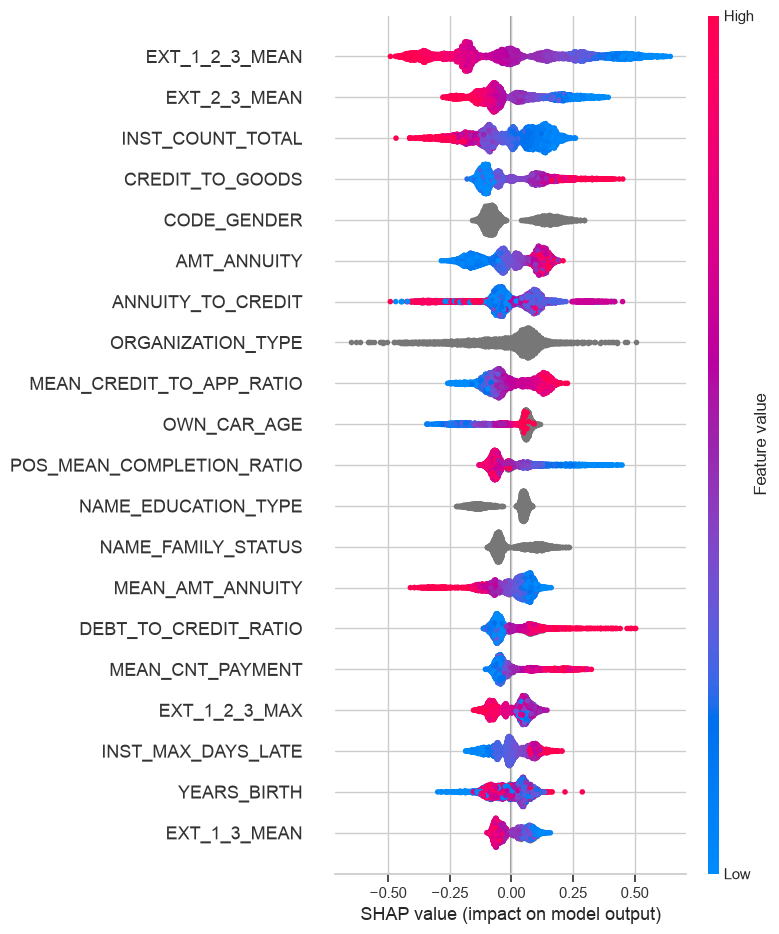

In [7]:
# TreeExplainer on a sample — 61k rows would be slow and unnecessary
sample_idx = np.random.RandomState(42).choice(len(Xc_hold), 5000, replace=False)
Xc_sample = Xc_hold.iloc[sample_idx]

explainer   = shap.TreeExplainer(lgb_final)
shap_values = explainer.shap_values(Xc_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Global importance
shap_imp = pd.DataFrame({
    "feature": Xc_sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

shap_imp["in_scorecard"] = shap_imp["feature"].isin(final_features)
print("--- Top 20 by mean |SHAP| ---")
print(shap_imp.head(20).to_string(index=False))

print(f"\nScorecard features in SHAP top 20: "
      f"{shap_imp.head(20)['in_scorecard'].sum()} of 24")

shap.summary_plot(shap_values, Xc_sample, max_display=20, show=False)
plt.tight_layout()
plt.savefig(FIGURES / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# --- Individual waterfall explanations ---
sample_targets = y_holdout.iloc[sample_idx].values
high_risk_idx = np.argsort(-explainer.expected_value - shap_values.sum(axis=1))[0]
low_risk_idx  = np.argsort(explainer.expected_value + shap_values.sum(axis=1))[0]

for label, idx in [("HIGHEST RISK", high_risk_idx), ("LOWEST RISK", low_risk_idx)]:
    print(f"\n{'='*70}")
    print(f"  {label} applicant   (actual TARGET = {sample_targets[idx]})")
    print(f"{'='*70}")
    contrib = pd.DataFrame({
        "feature": Xc_sample.columns,
        "value": Xc_sample.iloc[idx].values,
        "shap": shap_values[idx],
    }).reindex(np.abs(shap_values[idx]).argsort()[::-1]).head(10)
    print(contrib.to_string(index=False))


  HIGHEST RISK applicant   (actual TARGET = 0)
                   feature       value   shap
            EXT_1_2_3_MEAN      0.0615 0.5700
MAX_AMT_CREDIT_MAX_OVERDUE 75,627.0000 0.4165
POSITIVE_DAYS_REGISTRATION      2.0000 0.3619
              EXT_2_3_MEAN      0.0615 0.3614
              REFUSAL_RATE      0.8421 0.3333
             EXT_1_2_3_MIN      0.0510 0.2529
           CREDIT_TO_GOODS      1.2112 0.1808
          INST_COUNT_TOTAL     10.0000 0.1805
               CODE_GENDER           M 0.1410
          MEAN_CNT_PAYMENT     25.6923 0.1219

  LOWEST RISK applicant   (actual TARGET = 0)
              feature            value    shap
    ORGANIZATION_TYPE         Military -0.4760
       EXT_1_2_3_MEAN           0.7606 -0.4159
          OWN_CAR_AGE           3.0000 -0.2415
   NAME_FAMILY_STATUS        Separated  0.2111
          CODE_GENDER                M  0.1860
         EXT_2_3_MEAN           0.7606 -0.1623
  NAME_EDUCATION_TYPE Higher education -0.1505
       YEARS_EMPLOYED  

In [9]:
# --- REASON CODES from the scorecard ---
# For a declined applicant, the adverse-action reasons are the
# features where they lost the most points relative to the maximum
# achievable for that feature.

def reason_codes(applicant_row, scorecard_df, bp, features, top_n=4):
    woe_row = bp.transform(applicant_row[features].to_frame().T)
    max_pts = scorecard_df.groupby("feature")["points"].max()

    rows = []
    for feat in features:
        beta = coef_map[feat]
        pts  = -(beta * woe_row[feat].values[0] + alpha / n_feat) * factor + offset / n_feat
        rows.append({
            "feature": feat,
            "value": applicant_row[feat],
            "points": round(pts),
            "max_points": max_pts[feat],
            "points_lost": max_pts[feat] - round(pts),
        })
    return (pd.DataFrame(rows)
            .sort_values("points_lost", ascending=False)
            .head(top_n))


# Pick a declined applicant (score below the 90% approval cut-off ~535)
declined = score_df[score_df["score"] < 535].index[0]
applicant = X_holdout.iloc[declined]

print(f"\n{'='*70}")
print(f"  ADVERSE ACTION REASONS — applicant score {score_df.iloc[declined]['score']}")
print(f"{'='*70}")
print(reason_codes(applicant, scorecard, bp_final, final_features).to_string(index=False))


  ADVERSE ACTION REASONS — applicant score 523
                 feature  value  points  max_points  points_lost
           EXT_1_2_3_MIN 0.0701       4          40           36
            EXT_1_3_MEAN 0.3114      16          34           18
MEAN_CREDIT_TO_APP_RATIO 1.2022      15          29           14
       ANNUITY_TO_CREDIT 0.0544      22          34           12


In [11]:
# --- Score to PD mapping (deployment reference table) ---
lookup = []
for lo in range(450, 680, 10):
    band = score_df[(score_df["score"] >= lo) & (score_df["score"] < lo + 10)]
    if len(band) < 20:
        continue
    bad_rate = band["TARGET"].mean()
    odds = (1 - bad_rate) / bad_rate if bad_rate > 0 else np.inf
    lookup.append({
        "score_from":    lo,
        "score_to":      lo + 9,
        "n":             len(band),
        "bad_rate":      bad_rate,
        "good_bad_odds": odds,
        "cum_pct_pop":   (score_df["score"] < lo + 10).mean(),
    })

lookup_tbl = pd.DataFrame(lookup)
print(lookup_tbl.to_string(index=False))

# --- Save deliverables ---
lookup_tbl.to_csv(PROCESSED / "score_to_pd_lookup.csv", index=False)

score_df.drop(columns=["band"], errors="ignore").to_parquet(
    PROCESSED / "holdout_scores.parquet", index=False
)

shap_imp.to_csv(PROCESSED / "shap_importance.csv", index=False)

print("\nSaved:")
print("  score_to_pd_lookup.csv")
print("  holdout_scores.parquet")
print("  scorecard_points_table.csv")
print("  shap_importance.csv")

 score_from  score_to    n  bad_rate  good_bad_odds  cum_pct_pop
        470       479   30    0.6000         0.6667       0.0006
        480       489   97    0.4742         1.1087       0.0022
        490       499  301    0.3754         1.6637       0.0071
        500       509  804    0.3197         2.1284       0.0201
        510       519 1483    0.2549         2.9233       0.0443
        520       529 2702    0.2080         3.8078       0.0882
        530       539 4092    0.1696         4.8963       0.1547
        540       549 5678    0.1279         6.8209       0.2470
        550       559 7028    0.0918         9.8961       0.3613
        560       569 8380    0.0660        14.1537       0.4976
        570       579 8915    0.0472        20.1758       0.6425
        580       589 8192    0.0339        28.4676       0.7757
        590       599 6613    0.0254        38.3631       0.8832
        600       609 4257    0.0157        62.5373       0.9525
        610       619 203